In [1]:
import scipy.io as sio
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

We first need to write the functions needed to prepare the data 

In [64]:
def prepare_data(mat):
    data = sio.loadmat(mat)
    reponses_neuronales = data['stim'][0]['resp'][0] 
    identites_stimuli = data['stim'][0]['istim'][0].flatten()

    # ==========================================
    # 1. ISOLATE SPONTANEOUS ACTIVITY (WHITE NOISE)
    # ==========================================
    masque_spontane = identites_stimuli > 2800 
    X_spont = reponses_neuronales[masque_spontane]

    scaler = StandardScaler()
    X_spont_z = scaler.fit_transform(X_spont) 

    pca_spont = PCA(n_components=32)
    pca_spont.fit(X_spont_z) 
    axes_bruit = pca_spont.components_ 

    # ==========================================
    # 2. EXTRACT AND Z-SCORE VISUAL RESPONSES
    # ==========================================
    masque_images = identites_stimuli <= 2800
    ids_valides = identites_stimuli[masque_images] 
    reponses_valides = reponses_neuronales[masque_images]

    reponses_valides_z = scaler.transform(reponses_valides) 

    # ==========================================
    # 3. SPLIT: 1ST OCCURRENCE vs MEAN OF ALL OTHERS
    # ==========================================
    unique_ids, counts = np.unique(ids_valides, return_counts=True)
    
    # Only keep stimuli that were shown AT LEAST twice
    stimuli_communs = unique_ids[counts >= 2]
    #count the number of presentations for each image 
    counts_communs = counts[counts >= 2]
    X1_list = []
    X2_list = []
    final_ids = []
    
    for stim_id in stimuli_communs:
        # Get all temporal indices where this specific image was shown
        all_indices = np.where(ids_valides == stim_id)[0]
        
        # X1 gets the exact FIRST occurrence
        X1_list.append(reponses_valides_z[all_indices[0]])
        
        # X2 gets the MEAN of ALL SUBSEQUENT occurrences (from index 1 to the end)
        # This reduces trial-to-trial noise and creates a highly robust test sample
        mean_of_others = np.mean(reponses_valides_z[all_indices[1:]], axis=0)
        X2_list.append(mean_of_others)
        
        final_ids.append(stim_id)
        
    # Convert lists back to matrices
    X1_z = np.array(X1_list)
    X2_z = np.array(X2_list)
    final_ids = np.array(final_ids)

    return X1_z, X2_z, axes_bruit, final_ids,counts_communs

Once we separated between train and test sets on the number of presentations of the stimuli we clean the data by removing the spontaneous activity 

In [58]:
def clean_spontaneous_activity(X, axes_bruit):
    X1_z, X2_z = X
    projection_bruit_X1 = np.dot(X1_z, axes_bruit.T) #Projection of the training set on the noise axes
    projection_bruit_X2 = np.dot(X2_z, axes_bruit.T) #Projection of the test set on the noise axes

    bruit_reconstruit_X1 = np.dot(projection_bruit_X1, axes_bruit) #Reconstruction of the noise in the training set
    bruit_reconstruit_X2 = np.dot(projection_bruit_X2, axes_bruit) #Reconstruction of the noise in the test set

    X1_clean = X1_z - bruit_reconstruit_X1 #Subtraction of the noise from the training set
    X2_clean = X2_z - bruit_reconstruit_X2 #Subtraction of the noise from the test set
    return X1_clean, X2_clean

We then perform the same kind of PCA by performing classic PCA on the data from the first occurence and then projecting the neural responses of the other presentations of these axes

In [59]:

def PCA_cvPCA(X1_clean, X2_clean,n_components=None):
    pca_signal = PCA(n_components=n_components)
    pca_signal.fit(X1_clean) #perform PCA on the training set to get the signal axes

    projection_1 = pca_signal.transform(X1_clean) #Projection of the training set on the signal axes
    projection_2 = pca_signal.transform(X2_clean) #Projection of the test set on the signal axes

    variance_cvpca = np.mean(projection_1 * projection_2, axis=0) #compute the variance as in classic PCA 
    variance_cvpca = np.maximum(variance_cvpca, 1e-10)
    return variance_cvpca,pca_signal, projection_1, projection_2



need a normalization function to perform cosine similarity decoding 

In [60]:
def normalize_population_vectors(mat):
    #need to normalize the population vectors before computing the correlation matrix for the nearest neighbor decoder
    mat_centered = mat - np.mean(mat, axis=1, keepdims=True)
    norm = np.linalg.norm(mat_centered, axis=1, keepdims=True)
    norm[norm == 0] = 1e-10
    return mat_centered / norm

function of decoding using the PCs based on cosine similarity 

In [ ]:
def decoder_nearest_neighbor_PC(projection_1, projection_2, final_ids):


    #normalization of the train et test sets 
    train_norm = normalize_population_vectors(projection_1)
    test_norm = normalize_population_vectors(projection_2)

    #correlation matrix between the test and train sets (dot product of normalized vectors gives cosine similarity)
    correlation_matrix = np.dot(test_norm, train_norm.T)

    #prediction of the nearest neighbor for each test trial (index of the train trial with the highest correlation)
    best_match_indices = np.argmax(correlation_matrix, axis=1)

    # convert this matrix index (0 to 2365) into the actual stimulus ID using the final_ids array
    predicted_ids = final_ids[best_match_indices]
    
    #compting of the precision score 
    good_predictions = np.sum(predicted_ids == final_ids)
    precision = good_predictions / len(final_ids) #percentage of correct predictions
    return precision



In [ ]:
def decoder_nearest_neighbor(X1,X2, final_ids):
    
    # normalization of the train et test sets
    train_norm = normalize_population_vectors(X1)
    test_norm = normalize_population_vectors(X2)

    # correlation matrix between the test and train sets (dot product of normalized vectors gives cosine similarity)
    correlation_matrix = np.dot(test_norm, train_norm.T)
    #same as before but without PCA denoising, we directly compute the correlation matrix on the raw z-scored data
    best_match_indices = np.argmax(correlation_matrix, axis=1)
    predicted_ids = final_ids[best_match_indices]


    # precision score
    good_predictions = np.sum(predicted_ids == final_ids)
    precision = good_predictions / len(final_ids)
    return precision


In [ ]:
X1_z, X2_z, axes_bruit, final_ids,counts = prepare_data('6845348/natimg2800_M170714_MP032_2017-08-07.mat') #exemple with one mouse 
X1_clean, X2_clean = clean_spontaneous_activity((X1_z, X2_z), axes_bruit) #clean neural data with first functions 
variance_cvpca, pca_signal, projection_1, projection_2 = PCA_cvPCA(X1_clean, X2_clean) #perform cvPCA on the cleaned data

precision = decoder_nearest_neighbor_PC(projection_1, projection_2, final_ids)
print(f"Precision of decoding method (Nearest-Neighbor) : {precision * 100:.2f}%")
precision_nn = decoder_nearest_neighbor(X1_clean, X2_clean, final_ids)
print(f"Precision of decoding method (Nearest-Neighbor) on raw data : {precision_nn * 100:.2f}%")

Précision du décodage (Nearest-Neighbor) : 27.18%
Précision du décodage (Nearest-Neighbor) sur les données brutes : 32.36%


In [ ]:
files = ['6845348/natimg2800_M160825_MP027_2016-12-14.mat','6845348/natimg2800_M161025_MP030_2017-05-29.mat','6845348/natimg2800_M170604_MP031_2017-06-28.mat','6845348/natimg2800_M170714_MP032_2017-08-07.mat','6845348/natimg2800_M170714_MP032_2017-09-14.mat','6845348/natimg2800_M170717_MP033_2017-08-20.mat','6845348/natimg2800_M170717_MP034_2017-09-11.mat']
precisions_PC=[]
precisions=[]
for file in files:#itterate over all mice and compute the precision of the two decoding methods for each mouse
    X1_z, X2_z, axes_bruit, final_ids,counts = prepare_data(file)
    X1_clean, X2_clean = clean_spontaneous_activity((X1_z, X2_z), axes_bruit)
    variance_cvpca, pca_signal, projection_1, projection_2 = PCA_cvPCA(X1_clean, X2_clean)

    precision_PC = decoder_nearest_neighbor_PC(projection_1, projection_2, final_ids)
    precision = decoder_nearest_neighbor(X1_z, X2_z, final_ids)
    precisions_PC.append(precision_PC)
    precisions.append(precision)
    
    print(f"Precision of decoding method (Nearest-Neighbor with PCA) : {precision_PC * 100:.2f}%")
    print(f"Precision of decoding method (Nearest-Neighbor) : {precision * 100:.2f}%")

print(f"Mean PCA : {np.mean(precisions_PC) * 100:.2f}%, Standard Deviation PCA : {np.std(precisions_PC) * 100:.2f}%, Median PCA : {np.median(precisions_PC) * 100:.2f}%")
print(f"Mean : {np.mean(precisions) * 100:.2f}%, Standard Deviation : {np.std(precisions) * 100:.2f}%, Median : {np.median(precisions) * 100:.2f}")


Précision du décodage (Nearest-Neighbor with PCA) : 31.15%
Précision du décodage (Nearest-Neighbor) : 37.40%
Précision du décodage (Nearest-Neighbor with PCA) : 30.77%
Précision du décodage (Nearest-Neighbor) : 30.77%
Précision du décodage (Nearest-Neighbor with PCA) : 36.71%
Précision du décodage (Nearest-Neighbor) : 38.96%
Précision du décodage (Nearest-Neighbor with PCA) : 27.11%
Précision du décodage (Nearest-Neighbor) : 31.29%
Précision du décodage (Nearest-Neighbor with PCA) : 50.57%
Précision du décodage (Nearest-Neighbor) : 49.36%
Précision du décodage (Nearest-Neighbor with PCA) : 70.39%
Précision du décodage (Nearest-Neighbor) : 75.68%
Précision du décodage (Nearest-Neighbor with PCA) : 58.68%
Précision du décodage (Nearest-Neighbor) : 58.68%
Moyenne PCA : 43.63%, Écart-type PCA : 15.27%,Mediane PCA : 36.71%
Moyenne : 46.02%, Écart-type : 15.23%,Mediane : 38.96


We then wanted to link the max accuracy we could reach for every mouse with the number of times they were shown the stimuli expecting that the more data collected for one specific stimuli the easier it will be to decode it from the average of the n occurences 

In [ ]:

# Dictionnary to store the results for each group of presentation (2, 3, 4 and more)
categories_presentation = [2, 3, 4] 
results_per_groupe = {2: [], 3: [], 4: []}

for i, file in enumerate(files):
    X1_z, X2_z, axes_bruit, final_ids, counts_communs = prepare_data(file)
    X1_clean, X2_clean = clean_spontaneous_activity((X1_z, X2_z), axes_bruit)    
    # Decoding with the nearest neighbor method on the cleaned data (without PCA reduction, to get the max accuracy for analyzing the role of repetitions)
    precision = decoder_nearest_neighbor(X1_z, X2_z, final_ids)
    
    
    
    # compute the accuracy for each category of presentation and store it in the corresponding list in the results_per_groupe dictionary
    for cat in categories_presentation:
        masque_cat = (counts_communs == cat)
        if np.sum(masque_cat) > 0: # if the mouse has images seen 'cat' times
            acc_moyenne = np.mean(precision) * 100
            results_per_groupe[cat].append(acc_moyenne)
        else:
            results_per_groupe[cat].append(np.nan) # Pas de données pour cette catégorie
#Bar plot
labels = ['2 Repetitions', '3 Repetitions', '4 Repetitions or more']
colors = ['#4C72B0', '#55A868', '#C44E52']

# compute the means and standard errors (SEM) while ignoring potential NaN values
means = [np.nanmean(results_per_groupe[c]) for c in categories_presentation]
sds = [np.nanstd(results_per_groupe[c]) / np.sqrt(np.sum(~np.isnan(results_per_groupe[c]))) for c in categories_presentation]

plt.figure(figsize=(9, 6))


bars = plt.bar(labels, means, yerr=sds, capsize=6, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

# scatter of the individual points (one per mouse) for each category of presentation, with a small jitter on the x-axis to avoid superposition
for idx, cat in enumerate(categories_presentation):
    values_per_mouse = np.array(results_per_groupe[cat])
    # Filter Nans
    valid_values = values_per_mouse[~np.isnan(values_per_mouse)]
    
    # Jitter on the x-axis to avoid superposition of points
    x_jitter = np.random.normal(idx, 0.04, size=len(valid_values))
    plt.scatter(x_jitter, valid_values, color='black', alpha=0.7, zorder=3, s=40, label='Mouse' if idx==0 else "")


plt.title("Impact of the number of presentations on decoding accuracy", fontsize=15, pad=15)
plt.ylabel("Average correct precision (%)", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)


for i, rect in enumerate(bars):
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2., height + 2,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.legend()
plt.tight_layout()
plt.show()

TypeError: '>' not supported between instances of 'list' and 'int'

We then need a function to compute the decoding accuracy for each mouse as a function of the number of PCs used in the decoding algorithm

In [79]:
def PC_results_per_mouse(resolution=100):
    all_PC_results = []#one list per mouse to store the precision for each number of components
    N_stimuli=[]
    for file in files:
        # preparation of the data for each mouse (same as before)
        X1_z, X2_z, axes_bruit, final_ids,counts = prepare_data(file)
        X1_clean, X2_clean = clean_spontaneous_activity((X1_z, X2_z), axes_bruit)
        n_stimuli = X1_clean.shape[0]
        N_components = np.linspace(1, n_stimuli, num=resolution, dtype=int)
            
        # compute The PCA for each mouse with as many components as asked 
        variance_cvpca, pca_signal, projection_1, projection_2 = PCA_cvPCA(X1_clean, X2_clean, n_components=None)
        
        PC_results = []#list for storing the precision for each number of components for this mouse
        for n in N_components:
            # 3. LE SLICING MAGIQUE
            # On ne garde que les 'n' premières colonnes (les 'n' premières PC)
            proj_1_slice = projection_1[:, :n] #slicing of the PCA components for the training set
            proj_2_slice = projection_2[:, :n]
            
            # 4. Décodage sur le sous-ensemble
            precision_PC = decoder_nearest_neighbor_PC(proj_1_slice, proj_2_slice, final_ids) #decode with a subset of PCs
            PC_results.append(precision_PC)
            
        all_PC_results.append(PC_results)
        N_stimuli.append(n_stimuli)
    return all_PC_results,N_stimuli


Here we are plotting the decoding accuracy as a function of the number of PC used 

c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\function_base.py:302: RuntimeWarning: overflow encountered in power
  return _nx.power(base, y)
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\matplotlib\ticker.py:2468: RuntimeWarning: overflow encountered in power
  ticklocs = b ** decades


OverflowError: cannot convert float infinity to integer

<Figure size 800x600 with 1 Axes>

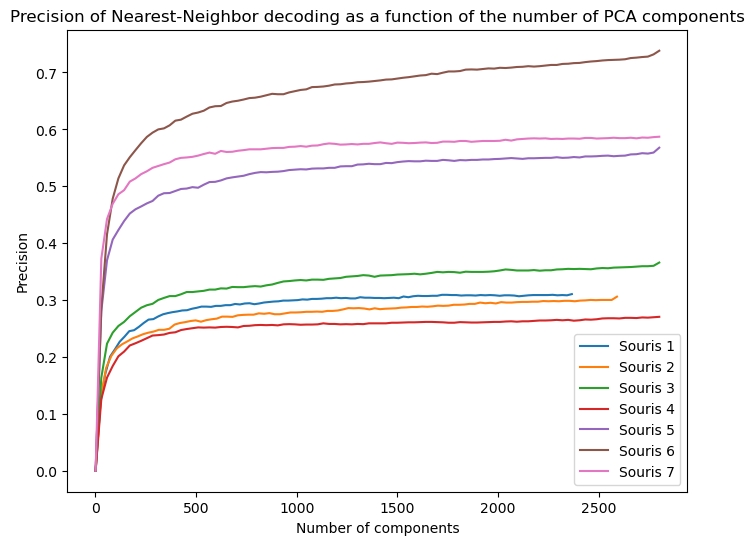

In [ ]:
resolution =100
global_PC_results,N_stimuli=PC_results_per_mouse(resolution=resolution)
global_PC_results,N_stimuli = np.array(global_PC_results),np.array(N_stimuli)


plt.figure(figsize=(8, 6))
for i, PC_results in enumerate(global_PC_results):
    plt.loglog(np.logspace(0,np.log10(N_stimuli[i]),num=resolution), PC_results, label=f'Souris {i+1}')
plt.xlabel('Number of components')
plt.ylabel('Precision')
plt.title('Precision of Nearest-Neighbor decoding as a function of the number of PCA components')
plt.legend()
plt.show()
plt.figure(figsize=(8, 6))

for i, PC_results in enumerate(global_PC_results):
    plt.plot(np.linspace(1,N_stimuli[i],num=resolution), PC_results, label=f'Souris {i+1}')
plt.xlabel('Number of components')
plt.ylabel('Precision')
plt.title('Precision of Nearest-Neighbor decoding as a function of the number of PCA components')
plt.savefig('precision_vs_components_linear.pdf', dpi=300)
plt.legend()
plt.show()

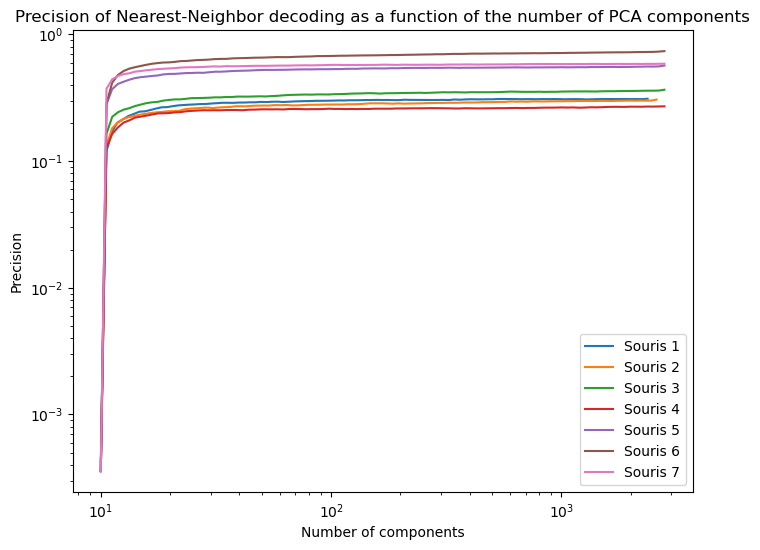

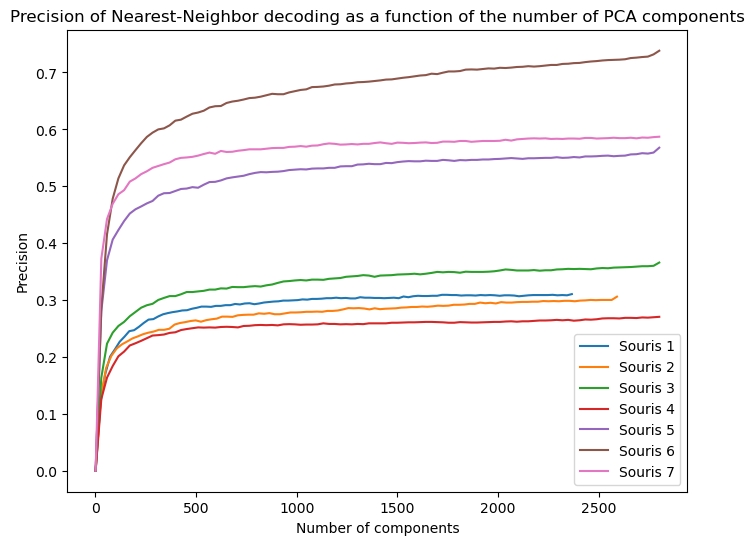

We now want to check is the decoding is the same when using the PCs with the highest variance or the lowest variance 

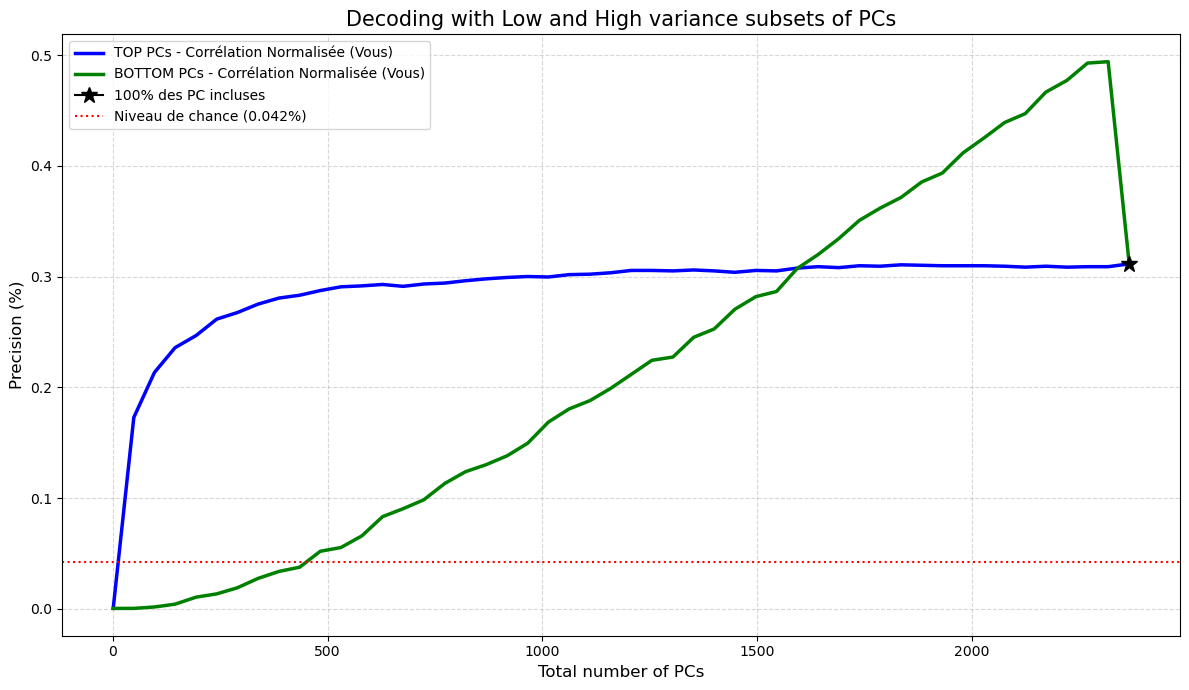

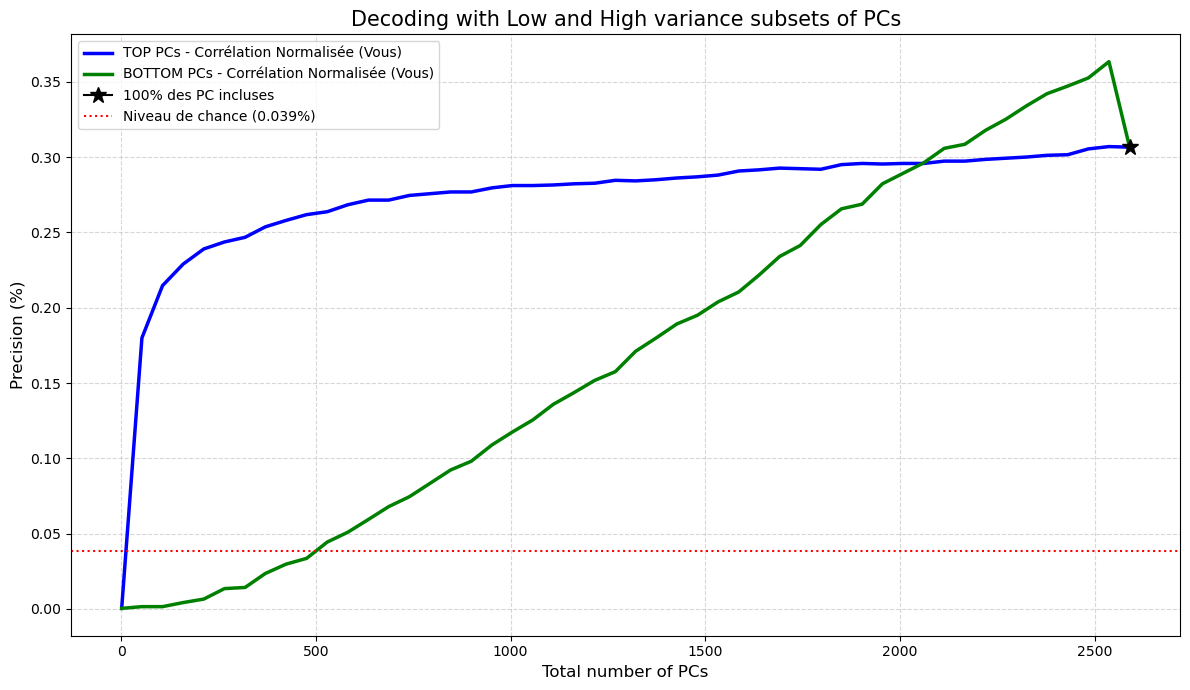

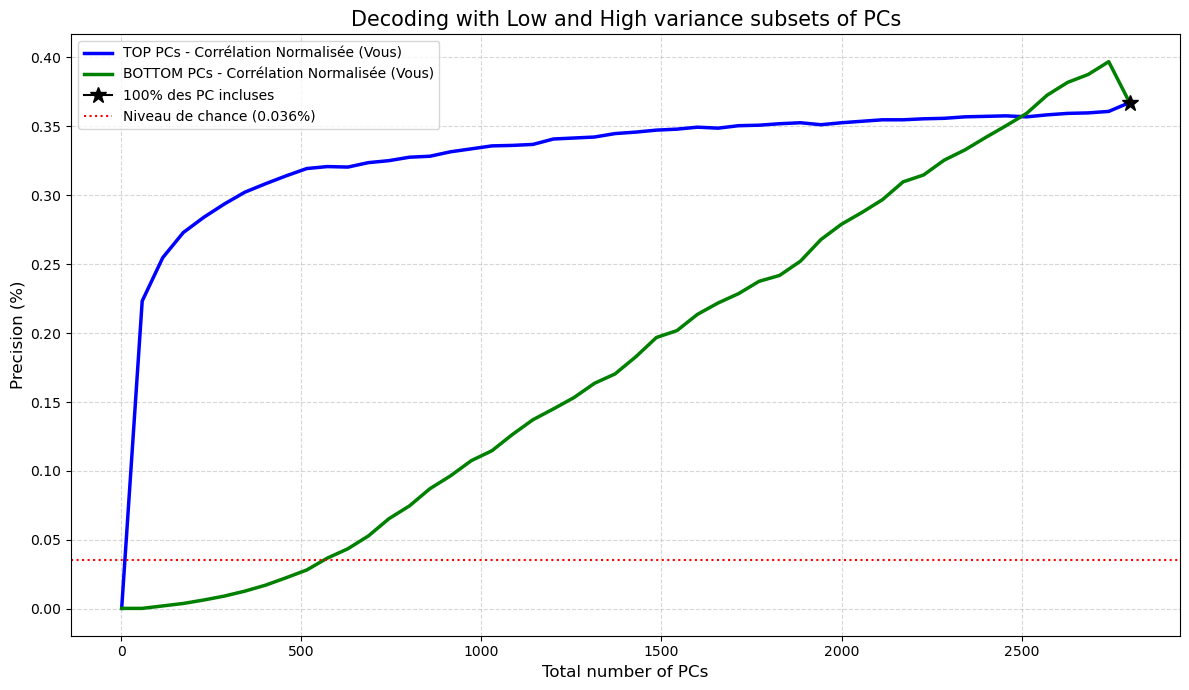

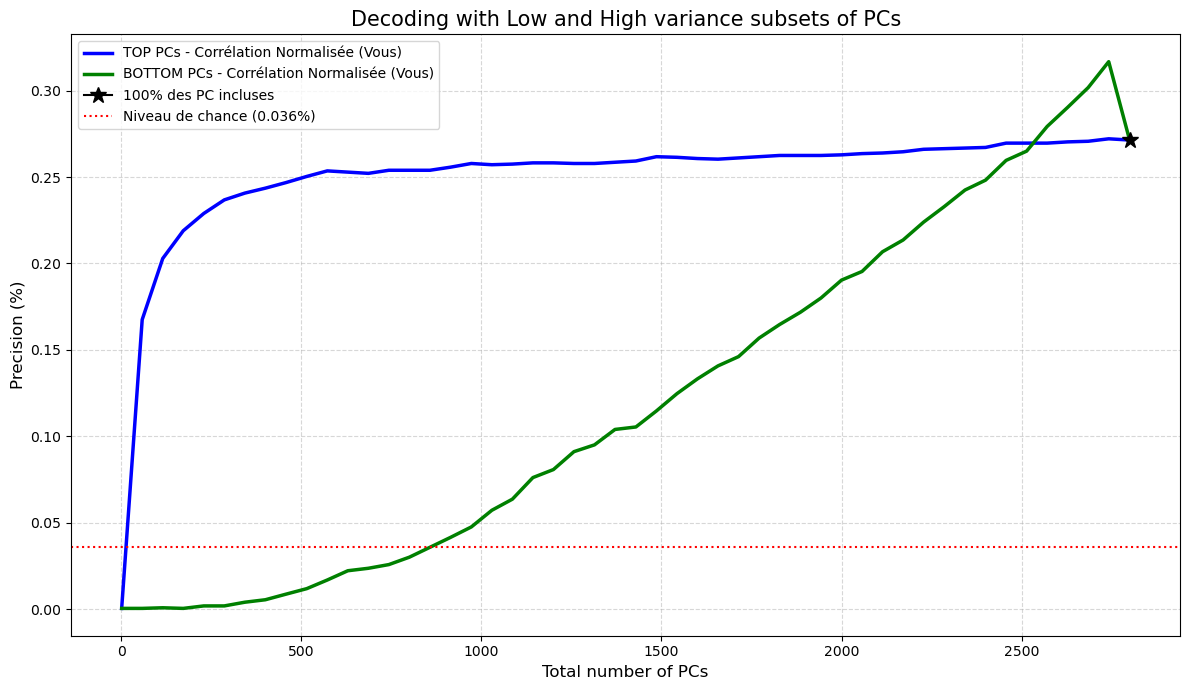

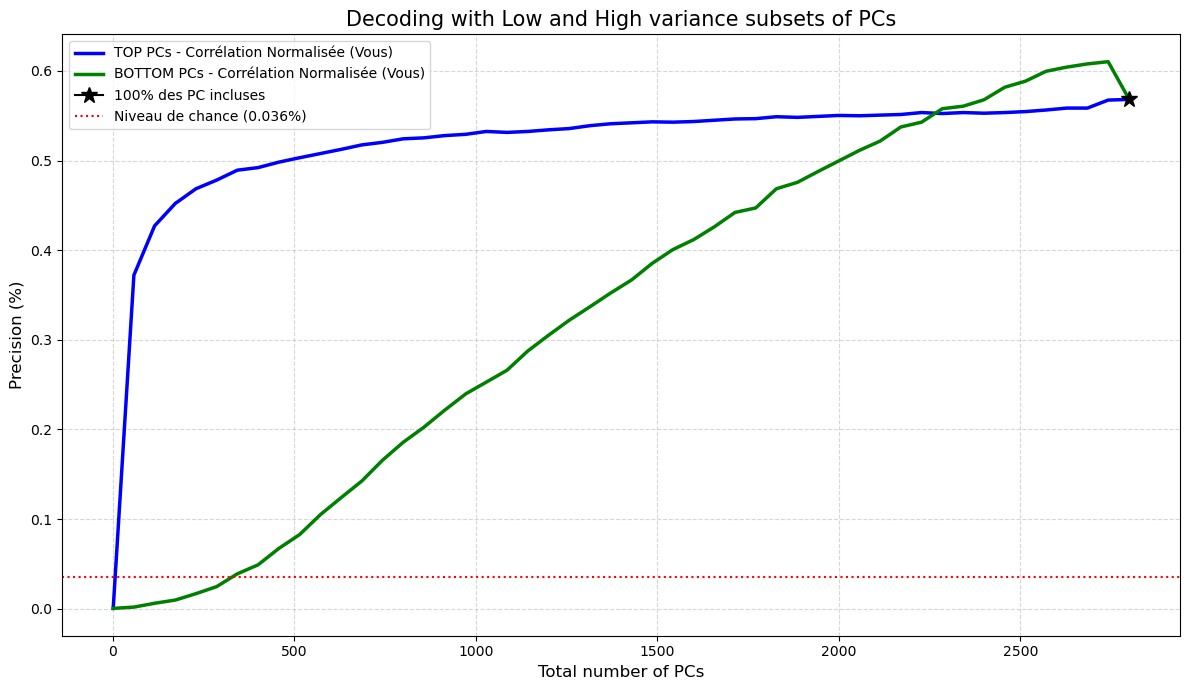

KeyboardInterrupt: 

In [96]:

for file in files:
    X1_z, X2_z, axes_bruit,final_ids,counts = prepare_data(file) #exemple with one mouse 
    X1_clean, X2_clean = clean_spontaneous_activity((X1_z, X2_z), axes_bruit) #clean neural data with first functions 
    variance_cvpca, pca_signal, projection_1, projection_2 = PCA_cvPCA(X1_clean, X2_clean) #perform cvPCA on the cleaned data

    cv_order = np.argsort(variance_cvpca)[::-1]  #sorting the PCs according to the variance of the cross validated PCA
    proj_1_cv = projection_1[:, cv_order]
    proj_2_cv = projection_2[:, cv_order]

 
    n_max = proj_1_cv.shape[1]
    ks = np.unique(np.linspace(1, n_max, num=50).astype(int)) #number of PCs
    if n_max not in ks:
        ks = np.append(ks, n_max)

    # Lists for the 2 kinds of results 
    acc_norm_top = []
    acc_norm_bot = []

    for k in ks:
        # k best PCs
        s1_top, s2_top = proj_1_cv[:, :k], proj_2_cv[:, :k]
        # k worst Pcs
        s1_bot, s2_bot = proj_1_cv[:, -k:], proj_2_cv[:, -k:]
        
        #decoding with this subset of PCs with high variance
        tn_top, testn_top = normalize_population_vectors(s1_top), normalize_population_vectors(s2_top)
        acc_norm_top.append(decoder_nearest_neighbor_PC(tn_top,testn_top,final_ids))
        

        # decoding with this subset of PCs with low variance
        tn_bot, testn_bot = normalize_population_vectors(s1_bot), normalize_population_vectors(s2_bot)
        acc_norm_bot.append(decoder_nearest_neighbor_PC(tn_bot,testn_bot,final_ids))
        


    #we make one plot per mouse to see fine details 
    plt.figure(figsize=(12, 7))

    # plot for the PC with highest variance
    plt.plot(ks, acc_norm_top, label='TOP PCs - Corrélation Normalisée (Vous)', color='blue', linewidth=2.5)

    # Plot for PCs with lowest variance
    plt.plot(ks, acc_norm_bot, label='BOTTOM PCs - Corrélation Normalisée (Vous)', color='green', linewidth=2.5)

    # accuracy with all available PCs for one mouse 
    plt.plot(n_max, acc_norm_top[-1], marker='*', color='black', markersize=12, label='100% des PC incluses')

    # Chance level line
    chance_level = (1 / len(final_ids)) * 100
    plt.axhline(chance_level, color='red', linestyle=':', label=f'Niveau de chance ({chance_level:.3f}%)')

    plt.title("Decoding with Low and High variance subsets of PCs", fontsize=15)
    plt.xlabel("Total number of PCs", fontsize=12)
    plt.ylabel("Precision (%)", fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [94]:
acc_norm_bot[-1]

np.float64(0.5867857142857142)

In [95]:
ks

array([   0,   57,  114,  171,  228,  285,  342,  400,  457,  514,  571,
        628,  685,  742,  800,  857,  914,  971, 1028, 1085, 1142, 1200,
       1257, 1314, 1371, 1428, 1485, 1542, 1600, 1657, 1714, 1771, 1828,
       1885, 1942, 2000, 2057, 2114, 2171, 2228, 2285, 2342, 2400, 2457,
       2514, 2571, 2628, 2685, 2742, 2800])